# Applying Regression Techniques to Fit Models on Real Datasets

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply regression techniques to fit models on real datasets
- Implement linear and polynomial regression
- Evaluate regression models using appropriate metrics
- Handle real-world data preprocessing for regression

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 01 "Regression vs Classification" — the same task you ran with one sklearn call, now with the mathematics of the fit in your hands.

**Used later in:** Course 04 (AIAT 114) — Unit 1 — the full regression toolkit (polynomial, ridge, lasso, SVR) built on this footing.

---

This notebook covers practical activities from **Course 03, Unit 3**:
- Applying regression techniques to fit models on real datasets

---

## Introduction

**Regression** is used to fit models that predict continuous values. This notebook demonstrates applying regression techniques to real-world datasets with proper preprocessing and evaluation.


---

## 📌 Real case: why this notebook does *not* use the Boston housing dataset

For decades, the default teaching dataset for regression was "Boston housing" — 506 census tracts,
13 features, predict the median home value. It shipped with scikit-learn as `load_boston`. It was
**deprecated in scikit-learn 1.0 and removed in 1.2**, and the library's own documentation states the
reason plainly: "The Boston housing prices dataset has an ethical problem: … the authors of this dataset
engineered a non-invertible variable 'B' assuming that racial self-segregation had a positive impact on
house prices" (scikit-learn documentation, `load_boston`). That variable is literally `B = 1000(Bk − 0.63)²`, where Bk is the proportion of Black
residents in the town — a squared term, so it cannot be inverted back to the proportion, and its shape
encodes an assumption about race and property value that the original 1978 paper never demonstrated.
scikit-learn now tells you to use the California housing data this notebook loads, or the Ames dataset,
and "strongly discourage[s] the use of this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning."

**What goes wrong without this.** A regression coefficient is a claim about the world. If a column encodes
a social assumption, your model launders that assumption into a number, and everyone downstream treats the
number as a measurement. Nothing in the fitting procedure will flag it. The only defence is reading what
the columns actually are — before `fit()`, not after deployment.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: pandas/NumPy for data handling, sklearn for models, scaling, and metrics,
# and the California Housing loader — a real dataset, not a toy.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.datasets import fetch_california_housing
import warnings
warnings.filterwarnings('ignore')
# Confirm the environment is ready before any math starts.
print("✅ Libraries imported!")
print("\nApplying Regression Techniques to Real Datasets")
print("=" * 60)


✅ Libraries imported!

Applying Regression Techniques to Real Datasets


## Part 1: Linear Regression on Real Dataset


Part 1: Linear Regression on Real Dataset

Loading California Housing dataset...
Dataset shape: (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: Median house value (in $100,000s)

First few rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  

Training samples: 16512
Test samples: 4128

Model Performance:

Training Set:
 MSE: 0.5179
 R²: 0.6126

Test Set:
 MSE: 0.5559
 R

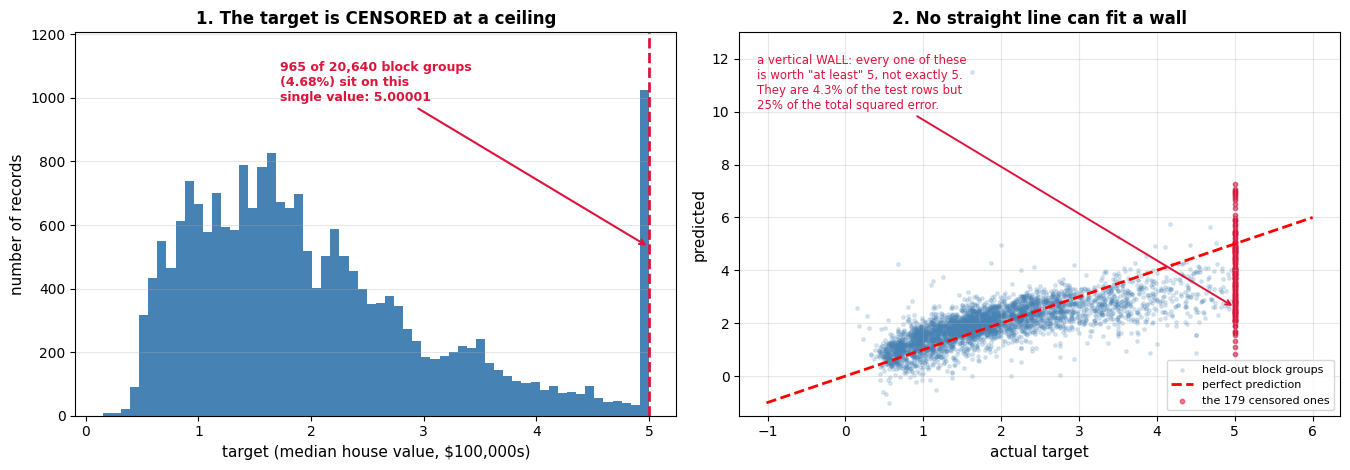


📊 The ceiling, in numbers: 965 of 20,640 records (4.68%) equal 5.00001.
   In the test set that is 179 rows (4.3%), and the model's average prediction for them is 3.87 —
   below the ceiling, because the ceiling is a recording rule, not a price.
   Those rows alone contribute 25% of the test squared error.


In [2]:
# The canonical regression workflow on real data: load California Housing, split train/test,
# standardize the features, fit a linear model, and evaluate on held-out data.

import pandas as pd
print("=" * 60)
print("Part 1: Linear Regression on Real Dataset")
print("=" * 60)

# Load California Housing dataset (real-world dataset)
print("\nLoading California Housing dataset...")
try:
 housing = fetch_california_housing()
 X, y = housing.data, housing.target
 feature_names = housing.feature_names
 print(f"Dataset shape: {X.shape}")
 print(f"Features: {feature_names}")
 print(f"Target: Median house value (in $100,000s)")
except Exception as err:
 # Fallback to a DIFFERENT REAL dataset, never to invented numbers: sklearn's diabetes
 # study ships with the library, so it works with no network access at all.
 from sklearn.datasets import load_diabetes
 print(f"California Housing unavailable ({type(err).__name__}).")
 print("Falling back to the real diabetes-progression dataset that ships with sklearn.")
 fallback = load_diabetes()
 X, y = fallback.data, fallback.target
 feature_names = list(fallback.feature_names)
 print(f"Dataset shape: {X.shape}")
 print(f"Features: {feature_names}")
 print("Target: Disease progression one year after baseline")

# Create DataFrame for easier handling
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"\nFirst few rows:")
print(df.head())
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train linear regression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predictions
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

# Evaluate
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print("\n" + "=" * 60)
print("Model Performance:")
print("=" * 60)
print(f"\nTraining Set:")
print(f" MSE: {train_mse:.4f}")
print(f" R²: {train_r2:.4f}")
print(f"\nTest Set:")
print(f" MSE: {test_mse:.4f}")
print(f" R²: {test_r2:.4f}")

print(f"\nCoefficients:")
for name, coef in zip(feature_names, model.coef_):
 print(f" {name}: {coef:.4f}")
print(f" Intercept: {model.intercept_:.4f}")

print("\n✅ Linear regression trained on real dataset!")


# ---------------------------------------------------------------------------------
# VISUAL: the one thing about this dataset that no metric on its own will tell you.
# WHAT: left, how the target values are distributed. Right, what the fitted model
# predicted for each held-out block group. WHY: the printed R² is a single number, and
# a single number cannot show you that a chunk of the target was recorded against a
# hard ceiling — which is the real reason this model cannot score better.
import matplotlib.pyplot as plt

cap_value = float(y.max())
n_capped = int((y == cap_value).sum())
capped_share = n_capped / len(y)
# A "ceiling" only exists if many rows pile up on the maximum. The diabetes fallback
# has no such pile-up, so the annotations below adapt instead of asserting something false.
has_ceiling = capped_share > 0.01

fig, (axh, axp) = plt.subplots(1, 2, figsize=(13.6, 4.8))

axh.hist(y, bins=60, color='steelblue', edgecolor='none')
if has_ceiling:
    axh.axvline(cap_value, color='crimson', ls='--', lw=2)
    # xytext in AXES FRACTION, not data units: a call-out placed in data units above the
    # tallest bar lands outside the frame and matplotlib squeezes the whole panel to fit it.
    axh.annotate(f'{n_capped:,} of {len(y):,} block groups\n({capped_share:.2%}) sit on this\n'
                 f'single value: {cap_value:.5f}',
                 xy=(cap_value, n_capped * 0.55), xytext=(0.34, 0.82),
                 textcoords='axes fraction', fontsize=9, color='crimson', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='crimson', lw=1.5))
    axh.set_ylim(0, n_capped * 1.25)
axh.set_xlabel(f'target ({"median house value, $100,000s" if has_ceiling else "value"})',
               fontsize=11)
axh.set_ylabel('number of records', fontsize=11)
axh.set_title('1. The target is CENSORED at a ceiling' if has_ceiling
              else '1. Distribution of the target', fontsize=12, fontweight='bold')
axh.grid(True, alpha=0.3, axis='y')

# Right: the same ceiling, seen from the model's side.
axp.scatter(y_test, y_pred_test, s=6, alpha=0.18, color='steelblue',
            label='held-out block groups')
lims = [float(min(y_test.min(), y_pred_test.min())), float(max(y_test.max(), 6.0))]
axp.plot(lims, lims, 'r--', lw=2, label='perfect prediction')
if has_ceiling:
    at_cap = y_test >= cap_value - 1e-6
    sse_share = ((y_pred_test[at_cap] - y_test[at_cap]) ** 2).sum() / \
                ((y_pred_test - y_test) ** 2).sum()
    axp.scatter(y_test[at_cap], y_pred_test[at_cap], s=10, alpha=0.55, color='crimson',
                label=f'the {int(at_cap.sum())} censored ones')
    axp.annotate(f'a vertical WALL: every one of these\nis worth "at least" {cap_value:.0f}, '
                 f'not exactly {cap_value:.0f}.\nThey are {at_cap.mean():.1%} of the test rows '
                 f'but\n{sse_share:.0%} of the total squared error.',
                 xy=(cap_value, 2.6), xytext=(0.03, 0.80), textcoords='axes fraction',
                 fontsize=8.5, color='crimson',
                 arrowprops=dict(arrowstyle='->', color='crimson', lw=1.4))
axp.set_xlabel('actual target', fontsize=11)
axp.set_ylabel('predicted', fontsize=11)
axp.set_title('2. No straight line can fit a wall', fontsize=12, fontweight='bold')
axp.set_ylim(-1.5, float(y_pred_test.max()) + 1.5)   # show every prediction, including the wild ones
axp.legend(fontsize=8, loc='lower right')
axp.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

if has_ceiling:
    at_cap = y_test >= cap_value - 1e-6
    print(f"\n📊 The ceiling, in numbers: {n_capped:,} of {len(y):,} records "
          f"({capped_share:.2%}) equal {cap_value}.")
    print(f"   In the test set that is {int(at_cap.sum())} rows ({at_cap.mean():.1%}), and the "
          f"model's average prediction for them is {y_pred_test[at_cap].mean():.2f} —")
    print(f"   below the ceiling, because the ceiling is a recording rule, not a price.")
    print(f"   Those rows alone contribute "
          f"{((y_pred_test[at_cap]-y_test[at_cap])**2).sum()/((y_pred_test-y_test)**2).sum():.0%} "
          f"of the test squared error.")

### 📊 What to see in the figure above

**Panel 1 — the spike on the right is not a data point, it is a rule.** The histogram of
the target falls away smoothly after $2 (in $100,000s) and then jumps to a single bar of
**965 records, 4.68% of the dataset, all holding the identical value 5.00001**. Nothing
natural produces a spike like that. It is the census recording rule: any block group worth
more than $500,000 was written down as $500,001.

**Panel 2 — the same rule, from the model's side.** Each faint dot is one held-out block
group. The red dots form a **vertical wall at actual = 5**: for those 179 test rows the
truth is "at least 5", but they are all recorded as exactly 5, so the model is scored
against a value that is not the real one. Its average prediction for them is 3.87, and
those 4.3% of rows contribute **25% of the total test squared error**. A quarter of this
model's apparent inaccuracy is a measurement artefact, not a modelling failure — which is
why no amount of extra polynomial degree or regularization in the next two sections moves
the score much. The correct fix is a censored-regression model, and it is out of scope
here; recognising the wall is not.

## Part 2: Polynomial Regression

Linear regression assumes a straight-line relationship. **Polynomial regression** adds powers of a feature (x², x³, …) so the model can bend.

Here we fit degrees 1-4 using a **single feature** (median income) so the fitted curves can be visualized. Watch two things in the output:
- **Train vs test R²**: if train keeps improving while test stalls or drops, the extra polynomial terms are overfitting.
- **Diminishing returns**: with one feature, the higher-degree terms add only a little — most of the signal in this dataset lives in the *other* features, not in a curvier income relationship.



Part 2: Polynomial Regression

Degree 1:
 Train R²: 0.4770
 Test R²: 0.4589

Degree 2:
 Train R²: 0.4816
 Test R²: 0.4633

Degree 3:
 Train R²: 0.4908
 Test R²: 0.4671

Degree 4:
 Train R²: 0.4909
 Test R²: 0.4673


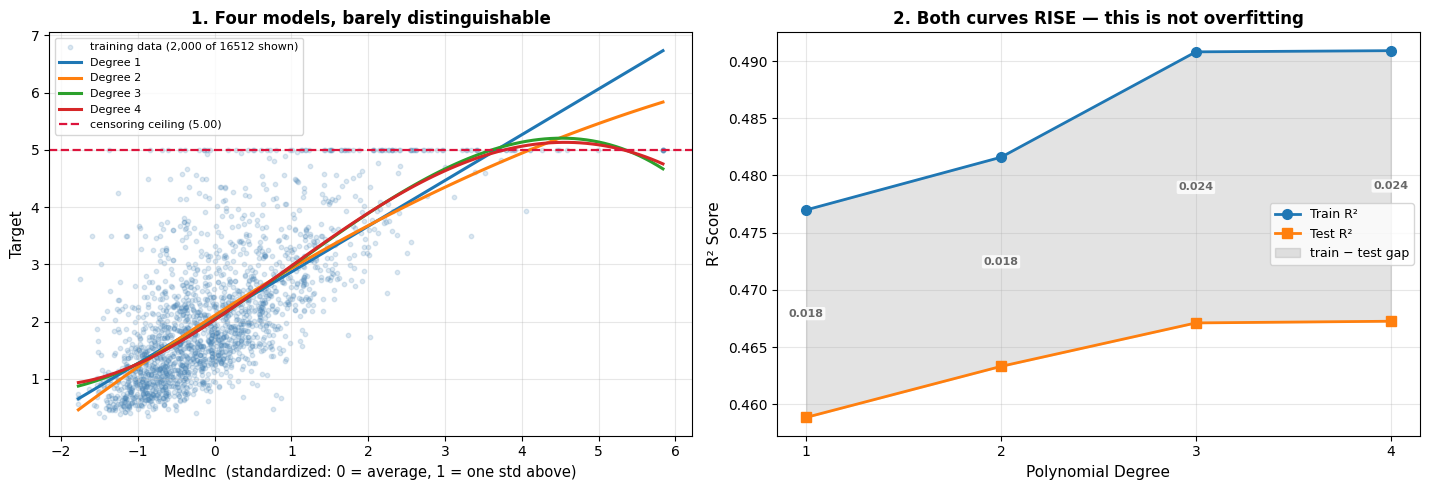


Total test-R² gained from degree 1 to degree 4: +0.0084
Train − test gap at each degree: deg 1: 0.0181, deg 2: 0.0183, deg 3: 0.0237, deg 4: 0.0236
The gap barely moves, so nothing here is overfitting. The extra degrees buy almost
nothing because the missing signal is in the OTHER seven features, not in a curvier
income relationship — and a difference this small needs a confidence interval before
anyone reports it as an improvement.

✅ Polynomial regression applied!


In [3]:
# Polynomial regression: raise the model's capacity degree by degree and watch train vs test R².
# Then look at whether the gap between train and test actually widens - the honest
# test for overfitting, and one this dataset does not fail.

print("\n" + "=" * 60)
print("Part 2: Polynomial Regression")
print("=" * 60)

# Use single feature for visualization
X_single = X_train_scaled[:, 0:1]
X_test_single = X_test_scaled[:, 0:1]

# Polynomial features
degrees = [1, 2, 3, 4]
results = []

# Fit one model per degree on a single feature (so the fitted curves can be drawn).
for degree in degrees:
 poly = PolynomialFeatures(degree=degree)
 X_train_poly = poly.fit_transform(X_single)
 X_test_poly = poly.transform(X_test_single)
 
 model_poly = LinearRegression()
 model_poly.fit(X_train_poly, y_train)
 
 y_pred_train = model_poly.predict(X_train_poly)
 y_pred_test = model_poly.predict(X_test_poly)
 
 train_r2 = r2_score(y_train, y_pred_train)
 test_r2 = r2_score(y_test, y_pred_test)
 
 results.append({
 'degree': degree, 'train_r2': train_r2,
 'test_r2': test_r2,
 'model': model_poly,
 'poly': poly
 })
 
 print(f"\nDegree {degree}:")
 print(f" Train R²: {train_r2:.4f}")
 print(f" Test R²: {test_r2:.4f}")

# Visualize
# Left: the fitted curves over the training cloud. Right: does more capacity actually help?
fig, (axl, axr) = plt.subplots(1, 2, figsize=(14.4, 5.0))

# WHY subsample: 16,512 training points at alpha 0.3 paint a solid blue slab and the
# fitted curves disappear into it. 2,000 points show the same shape and leave the
# curves visible. The model is still fitted on all of them.
rng = np.random.default_rng(0)
sub = rng.choice(len(X_single), size=min(2000, len(X_single)), replace=False)
axl.scatter(X_single[sub], y_train[sub], alpha=0.18, s=10, color='steelblue',
            label='training data (2,000 of %d shown)' % len(X_single))
x_plot = np.linspace(X_single.min(), X_single.max(), 100).reshape(-1, 1)
for r in results:
    x_plot_poly = r['poly'].transform(x_plot)
    y_plot = r['model'].predict(x_plot_poly)
    axl.plot(x_plot, y_plot, label=f'Degree {r["degree"]}', linewidth=2.2)
# The ceiling again — it is the flat band of points along the top, and no curve can reach it.
if float(y_train.max()) == float(y_train.max()):
    axl.axhline(y_train.max(), color='crimson', ls='--', lw=1.6,
                label=f'censoring ceiling ({y_train.max():.2f})')
axl.set_xlabel(f'{feature_names[0]}  (standardized: 0 = average, 1 = one std above)', fontsize=10.5)
axl.set_ylabel('Target', fontsize=11)
axl.set_title('1. Four models, barely distinguishable', fontsize=12, fontweight='bold')
axl.legend(fontsize=8, loc='upper left')
axl.grid(True, alpha=0.3)

# Right: train vs test R², with an HONEST reading of the gap.
degrees_list = [r['degree'] for r in results]
train_r2_list = [r['train_r2'] for r in results]
test_r2_list = [r['test_r2'] for r in results]
axr.plot(degrees_list, train_r2_list, 'o-', label='Train R²', linewidth=2, markersize=7)
axr.plot(degrees_list, test_r2_list, 's-', label='Test R²', linewidth=2, markersize=7)
# Shade the gap so its CONSTANT width is the thing you notice. Overfitting would make
# this band widen to the right; here it does not, and the picture has to say so.
axr.fill_between(degrees_list, test_r2_list, train_r2_list, color='grey', alpha=0.22,
                 label='train − test gap')
gaps = [t - v for t, v in zip(train_r2_list, test_r2_list)]
for d, t, v, g in zip(degrees_list, train_r2_list, test_r2_list, gaps):
    axr.annotate(f'{g:.3f}', xy=(d, (t + v) / 2), fontsize=8, ha='center', va='center',
                 color='dimgrey', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.8))
axr.set_xticks(degrees_list)          # degree 1.5 does not exist; do not draw a tick for it
axr.set_xlabel('Polynomial Degree', fontsize=11)
axr.set_ylabel('R² Score', fontsize=11)
axr.set_title('2. Both curves RISE — this is not overfitting', fontsize=12, fontweight='bold')
axr.legend(fontsize=9, loc='center right')
axr.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTotal test-R² gained from degree 1 to degree {degrees_list[-1]}: "
      f"{test_r2_list[-1] - test_r2_list[0]:+.4f}")
print(f"Train − test gap at each degree: "
      + ", ".join(f'deg {d}: {g:.4f}' for d, g in zip(degrees_list, gaps)))
print("The gap barely moves, so nothing here is overfitting. The extra degrees buy almost")
print("nothing because the missing signal is in the OTHER seven features, not in a curvier")
print("income relationship — and a difference this small needs a confidence interval before")
print("anyone reports it as an improvement.")

print("\n✅ Polynomial regression applied!")

### 📊 What to see in the figure above

**Panel 1 — four models you can barely tell apart.** The cloud is 2,000 randomly drawn
training block groups (the models are fitted on all 16,512). The four fitted curves lie
almost on top of one another below `MedInc = 3`, where nearly all the data sits; they only
fan out on the right, where there is hardly any data to disagree about. The crimson dashed
line is the censoring ceiling from Part 1 — notice that the degree-3 and degree-4 curves
bend to *chase* it and still cannot reach the flat band of points sitting on it.

**Panel 2 — the honest test for overfitting, and this fails it.** Train R² (blue) and test
R² (orange) both **rise** from degree 1 to degree 4; the grey band between them is the
train − test gap, printed at each degree: **0.018, 0.018, 0.024, 0.024**. Overfitting looks
like that band *widening* to the right while the orange line turns down. It does neither.
Total test-R² gained across three added degrees: **+0.0084** — smaller than the shift a
different train/test split would produce. So the correct conclusion is not "degree 4 is
better"; it is "capacity was never the constraint here". The missing signal lives in the
other seven features, which this single-feature demo deliberately threw away.

## Part 3: Regularized Regression (Ridge and Lasso)

**Regularization** adds a penalty on large weights to the loss, controlled by the strength α:
- **Ridge** (L2 penalty) shrinks all weights smoothly toward zero.
- **Lasso** (L1 penalty) can drive weights *exactly* to zero — it performs feature selection.

How to read the sweep below:
- **Ridge barely moves** across this α range — with 8 informative, scaled features and ~16k training samples, the unregularized fit is already stable, so mild shrinkage changes little.
- **Lasso collapses at large α**: once the penalty dominates, it zeroes out *every* coefficient. The model then predicts a constant (the mean of the training targets), and test R² falls to ≈ 0 — the score of always guessing the mean. It can even go slightly *negative*, because the training mean is not exactly the test mean.

**Takeaway**: regularization strength is a dial, not a free win — too much destroys the model. Tune α on validation data.



Part 3: Regularized Regression (Ridge and Lasso)

Ridge Regression Results:
 Alpha  0.001: R² = 0.5758
 Alpha  0.010: R² = 0.5758
 Alpha  0.100: R² = 0.5758
 Alpha  1.000: R² = 0.5758
 Alpha 10.000: R² = 0.5761
 Alpha 100.000: R² = 0.5778

Lasso Regression Results:
 Alpha  0.001: R² = 0.5769
 Alpha  0.010: R² = 0.5816
 Alpha  0.100: R² = 0.4814
 Alpha  1.000: R² = -0.0002
 Alpha 10.000: R² = -0.0002
 Alpha 100.000: R² = -0.0002


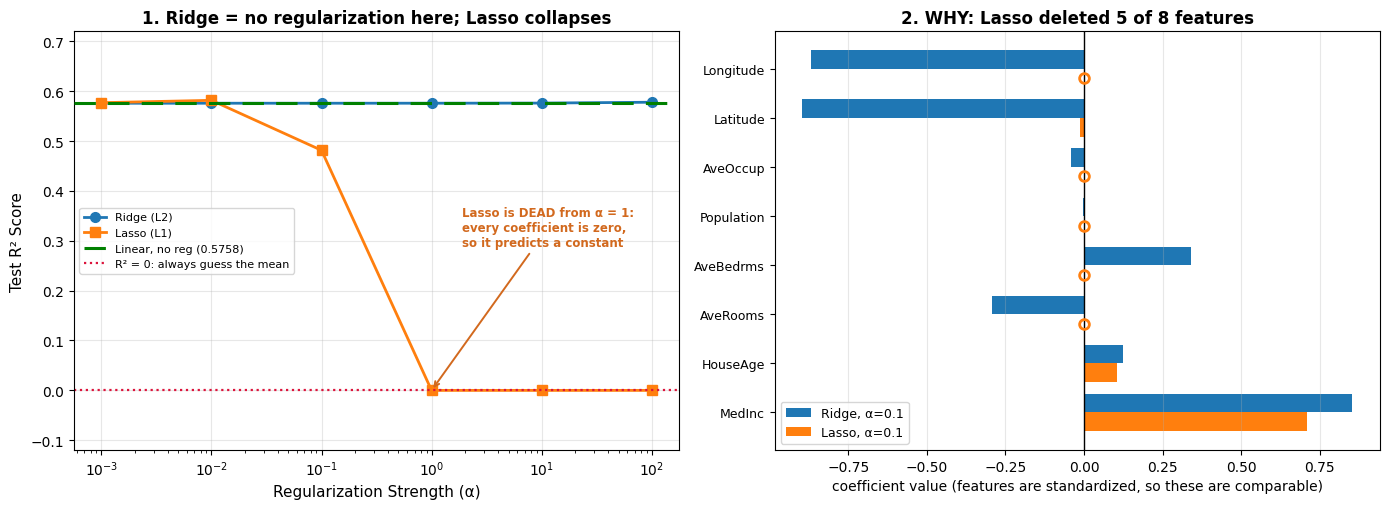


Unregularized linear baseline on the test set: R² = 0.5758
Ridge at every α tested: R² = 0.5758 to 0.5778 — indistinguishable from the baseline.
With 8 scaled, informative features and 16,512 rows, there is nothing to regularize.

Non-zero coefficients kept at each α:
   alpha |  Ridge |  Lasso
--------------------------
   0.001 |      8 |      8
    0.01 |      8 |      7
     0.1 |      8 |      3
     1.0 |      8 |      0
    10.0 |      8 |      0
   100.0 |      8 |      0

At α = 0.1, Lasso zeroed: AveRooms, AveBedrms, Population, AveOccup, Longitude
Ridge's weights for those same features: AveRooms=-0.29, AveBedrms=0.34, Population=-0.00, AveOccup=-0.04, Longitude=-0.87
That is the trade: L1 gives you a shorter feature list, and charges you whatever
those deleted features were worth.

✅ Regularized regression applied!


In [4]:
# Regularized regression: sweep alpha for Ridge (L2) and Lasso (L1) and compare test R².
# Regularization tames the wiggle room that made the high-degree models overfit.

print("\n" + "=" * 60)
print("Part 3: Regularized Regression (Ridge and Lasso)")
print("=" * 60)

# Compare Ridge and Lasso
alpha_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

ridge_results = []
lasso_results = []

for alpha in alpha_values:
 # Ridge
 ridge = Ridge(alpha=alpha)
 ridge.fit(X_train_scaled, y_train)
 y_pred_ridge = ridge.predict(X_test_scaled)
 ridge_r2 = r2_score(y_test, y_pred_ridge)
 ridge_results.append({'alpha': alpha, 'r2': ridge_r2, 'model': ridge})
 
 # Lasso
 lasso = Lasso(alpha=alpha, max_iter=2000)
 lasso.fit(X_train_scaled, y_train)
 y_pred_lasso = lasso.predict(X_test_scaled)
 lasso_r2 = r2_score(y_test, y_pred_lasso)
 lasso_results.append({'alpha': alpha, 'r2': lasso_r2, 'model': lasso})

# Report each alpha; note how performance degrades once alpha over-shrinks the weights.
print("\nRidge Regression Results:")
for r in ridge_results:
 print(f" Alpha {r['alpha']:6.3f}: R² = {r['r2']:.4f}")

print("\nLasso Regression Results:")
for r in lasso_results:
 print(f" Alpha {r['alpha']:6.3f}: R² = {r['r2']:.4f}")

# Visualize
fig, (axa, axb) = plt.subplots(1, 2, figsize=(14.0, 5.2))

ridge_alphas = [r['alpha'] for r in ridge_results]
ridge_r2s = [r['r2'] for r in ridge_results]
lasso_alphas = [r['alpha'] for r in lasso_results]
lasso_r2s = [r['r2'] for r in lasso_results]
axa.semilogx(ridge_alphas, ridge_r2s, 'o-', label='Ridge (L2)', linewidth=2, markersize=7)
axa.semilogx(lasso_alphas, lasso_r2s, 's-', label='Lasso (L1)', linewidth=2, markersize=7)
# Recompute the unregularized baseline HERE rather than reusing `test_r2`: the
# polynomial loop in Part 2 rebound that name to the degree-4 score, so the old version
# of this plot drew a line at 0.467 and labelled it "Linear (no reg)" — a wrong number
# under a correct-sounding label, which is the worst kind of chart.
_baseline = LinearRegression().fit(X_train_scaled, y_train)
linear_test_r2 = r2_score(y_test, _baseline.predict(X_test_scaled))
# Drawn with long dashes ON TOP of Ridge, because it lands exactly on the Ridge line and
# a thin line underneath would simply vanish.
axa.axhline(y=linear_test_r2, color='g', linestyle=(0, (7, 4)), lw=2.2, zorder=5,
            label=f'Linear, no reg ({linear_test_r2:.4f})')
axa.axhline(y=0.0, color='crimson', linestyle=':', lw=1.6,
            label='R² = 0: always guess the mean')
axa.annotate('Lasso is DEAD from α = 1:\nevery coefficient is zero,\nso it predicts a constant',
             xy=(1.0, lasso_r2s[3]), xytext=(1.9, 0.29), fontsize=8.5, color='chocolate',
             fontweight='bold', ha='left',
             arrowprops=dict(arrowstyle='->', color='chocolate', lw=1.4))
axa.set_xlabel('Regularization Strength (α)', fontsize=11)
axa.set_ylabel('Test R² Score', fontsize=11)
axa.set_title('1. Ridge = no regularization here; Lasso collapses', fontsize=12,
              fontweight='bold')
axa.set_ylim(-0.12, 0.72)
axa.legend(fontsize=8, loc='center left')
axa.grid(True, alpha=0.3)

# --- Panel 2: WHY it collapses — the coefficients themselves ----------------------
# WHAT: every feature's weight under Ridge and under Lasso at the SAME alpha. WHY: the
# markdown above claims "L1 can drive weights exactly to zero". This is that claim,
# drawn — and it explains panel 1, because the features Lasso deletes are the ones
# Ridge is leaning on hardest.
alpha_show = 0.1
ridge_show = next(r['model'] for r in ridge_results if r['alpha'] == alpha_show)
lasso_show = next(r['model'] for r in lasso_results if r['alpha'] == alpha_show)
pos = np.arange(len(feature_names))
h = 0.38
axb.barh(pos + h / 2, ridge_show.coef_, height=h, color='tab:blue', label=f'Ridge, α={alpha_show}')
axb.barh(pos - h / 2, lasso_show.coef_, height=h, color='tab:orange', label=f'Lasso, α={alpha_show}')
axb.axvline(0, color='black', lw=1)
axb.set_yticks(pos)
axb.set_yticklabels(feature_names, fontsize=9)
n_zero = int((lasso_show.coef_ == 0).sum())
# Mark each coefficient Lasso set to EXACTLY zero, so "exactly zero" is visible.
for j, cf in enumerate(lasso_show.coef_):
    if cf == 0:
        axb.plot(0, j - h / 2, marker='o', ms=7, mfc='none', mec='tab:orange', mew=2,
                 zorder=5)
axb.set_xlabel('coefficient value (features are standardized, so these are comparable)',
               fontsize=10)
axb.set_title(f'2. WHY: Lasso deleted {n_zero} of {len(feature_names)} features',
              fontsize=12, fontweight='bold')
axb.legend(fontsize=9, loc='lower left')
axb.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"\nUnregularized linear baseline on the test set: R² = {linear_test_r2:.4f}")
print(f"Ridge at every α tested: R² = {min(r['r2'] for r in ridge_results):.4f} to "
      f"{max(r['r2'] for r in ridge_results):.4f} — indistinguishable from the baseline.")
print("With 8 scaled, informative features and 16,512 rows, there is nothing to regularize.")
print("\nNon-zero coefficients kept at each α:")
print(f"{'alpha':>8} | {'Ridge':>6} | {'Lasso':>6}")
print("-" * 26)
for r, l in zip(ridge_results, lasso_results):
    print(f"{r['alpha']:>8} | {int((r['model'].coef_ != 0).sum()):>6} | "
          f"{int((l['model'].coef_ != 0).sum()):>6}")
print(f"\nAt α = {alpha_show}, Lasso zeroed: "
      + ", ".join(n for n, c in zip(feature_names, lasso_show.coef_) if c == 0))
print(f"Ridge's weights for those same features: "
      + ", ".join(f"{n}={c:.2f}" for n, c in zip(feature_names, ridge_show.coef_)
                  if lasso_show.coef_[list(feature_names).index(n)] == 0))
print("That is the trade: L1 gives you a shorter feature list, and charges you whatever")
print("those deleted features were worth.")

print("\n✅ Regularized regression applied!")

### 📊 What to see in the figure above

**Panel 1 — Ridge does nothing, and that is the finding.** The green long-dashed line is
the *unregularized* linear model, `R² = 0.5758`. The blue Ridge curve lies exactly on top
of it at every α from 0.001 to 100 — you can see the green dashes showing through the blue
line rather than a separate level. With 8 standardized, informative features and 16,512
training rows, there is no instability for L2 to damp, so the penalty buys nothing. The
orange Lasso curve does something quite different: a small gain at `α = 0.01`
(`R² = 0.5816`, its best), a stumble at `α = 0.1` (`0.4814`), and then it falls onto the red
dotted `R² = 0` line and stays there. R² = 0 is the score of always predicting the training
mean, so the model is no longer a model.

**Panel 2 — why it died.** These are the eight coefficients at the same `α = 0.1`, blue for
Ridge and orange for Lasso, on standardized features so the lengths are comparable. **Five
of the orange bars are not short — they are exactly zero**, each marked with a hollow
orange ring on the zero line: `AveRooms`, `AveBedrms`, `Population`, `AveOccup` and
`Longitude`. Now look at the blue bars for those same features: Ridge gives `Longitude`
a weight of **−0.87**, one of the two largest in the model. L1 deleted the second-strongest
predictor in the dataset. That is the trade in one picture: Lasso hands you a shorter
feature list and charges you whatever the deleted features were worth.

---

## ⚠️ Where this breaks

- **This target is censored, and the notebook's R² is quietly paying for it.** California median house
  value is capped: the maximum is exactly 5.00001 ($500,001), and **965 of the 20,640 block groups
  (4.68%) sit at that ceiling**. Check it yourself: `(y == y.max()).sum()`. Those are not neighbourhoods
  worth half a million dollars — they are neighbourhoods worth *at least* that, recorded as if they were
  all identical. No linear model can fit a flat wall, and no amount of regularization or polynomial degree
  will help. The right tool for a censored target is a censored-regression model, not a better R².
- **Lasso at α ≥ 1 gives R² = −0.0002 — the model has died.** Read the sweep: R² goes 0.5816 (α=0.01) →
  0.4814 (α=0.1) → −0.0002 (α=1.0). At that point the L1 penalty has zeroed every coefficient and the model
  predicts a constant, so it scores marginally *worse* than always predicting the training mean. Negative R²
  is not a rounding error; it is the metric telling you the model is worse than useless.
- **The polynomial "improvement" is inside the noise.** Degrees 1 → 4 moved test R² from 0.4589 to 0.4673
  on a single split. That is 0.008 — comparable to what re-splitting the data would move it. The notebook
  itself says most of the signal lives in the *other* features, not in a curvier income relationship. Do
  not report a difference this small without a confidence interval (Unit 5, notebook 02).
- **1990 California is not 2026 Riyadh.** Every coefficient here is conditional on a place, a decade, a
  currency and a housing market. Transferring a fitted model across any of those is an untested assumption,
  and "it worked on the test set" tests none of them.


---

## 💬 Discuss

1. scikit-learn kept the Boston dataset for decades, then removed it — and now recommends it only for
   teaching about ethics. Was removing it the right call, or does deleting a flawed dataset make the
   problem harder to see? Argue one side properly.
2. Nearly 5% of this dataset's targets sit on an artificial ceiling. Suppose you had not noticed. Describe
   the specific way your model's predictions would be wrong, and who would be harmed by it.
3. A Saudi property developer asks you to reuse this model's structure for Jeddah. List, in order, the
   three things you would insist on checking before agreeing — and say which one you expect to fail.


## Summary

### Key Concepts:
1. **Linear Regression**: Fits a linear model to data
2. **Polynomial Regression**: Captures non-linear relationships
3. **Regularized Regression**: Prevents overfitting (Ridge, Lasso)
4. **Model Evaluation**: Use R², MSE, MAE metrics
5. **Data Preprocessing**: Scaling is important for regression

### Best Practices:
- Always split data into train/test sets
- Scale features before training
- Use regularization to prevent overfitting
- Evaluate on test set, not training set
- Visualize results to understand model behavior

### Applications:
- House price prediction
- Sales forecasting
- Temperature prediction
- Any continuous value prediction

**Reference:** Course 03, Unit 3: "Optimization and Statistical Foundations" - Regression on real datasets practical content

## 📚 References

1. Hoerl, A. E., & Kennard, R. W. (1970). *Ridge Regression: Biased Estimation for Nonorthogonal Problems*. Technometrics, 12(1), 55–67.
2. Tibshirani, R. (1996). *Regression Shrinkage and Selection via the Lasso*. Journal of the Royal Statistical Society, Series B, 58(1), 267–288.
3. Pace, R. K., & Barry, R. (1997). *Sparse Spatial Autoregressions*. Statistics & Probability Letters, 33(3), 291–297.
4. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Ch. 3 and Ch. 6. Springer. <https://www.statlearning.com/>
5. Grinsztajn et al. (2022). *Why do tree-based models still outperform deep learning on tabular data?* arXiv. <https://arxiv.org/abs/2207.08815> — the honest baseline: why tree ensembles beat deep models on medium-sized tabular data.
6. Grinsztajn et al. (2025). *TabPFN-2.5: Advancing the State of the Art in Tabular Foundation Models*. arXiv. <https://arxiv.org/abs/2511.08667> — the 2025 challenger to that baseline: a pretrained tabular model that needs no per-dataset fitting.
